# COCO Detection EDA

Notebook này dùng để xem nhanh COCO annotation theo kiểu trực quan: số lượng ảnh, số object, class distribution, bbox stats, và vài ảnh mẫu có bounding boxes.

Chạy notebook này từ folder `my_work/yolov1_coco` để các path mặc định hoạt động.

In [100]:
from pathlib import Path
import json
import random
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

ANNOTATION_PATH = Path("coco_raw/annotations/instances_val2017.json")
IMAGE_DIR = Path("coco_raw/val2017")

random.seed(123)
pd.set_option("display.max_columns", 50)

print(ANNOTATION_PATH.exists(), ANNOTATION_PATH)
print(IMAGE_DIR.exists(), IMAGE_DIR)

True coco_raw/annotations/instances_val2017.json
True coco_raw/val2017


## 1. Load JSON Và Xem Cấu Trúc

In [101]:
with ANNOTATION_PATH.open("r") as f:
    coco = json.load(f)

print(coco.keys())

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])


In [102]:
print("images:", len(coco["images"]))
print("annotations:", len(coco["annotations"]))
print("categories:", len(coco["categories"]))

images: 5000
annotations: 36781
categories: 80


In [103]:
print("Sample image record:")
display(coco["images"][0])

Sample image record:


{'license': 4,
 'file_name': '000000397133.jpg',
 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg',
 'height': 427,
 'width': 640,
 'date_captured': '2013-11-14 17:02:52',
 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg',
 'id': 397133}

In [104]:
print("Sample annotation record:")
display(coco["annotations"][0])

Sample annotation record:


{'segmentation': [[510.66,
   423.01,
   511.72,
   420.03,
   510.45,
   416.0,
   510.34,
   413.02,
   510.77,
   410.26,
   510.77,
   407.5,
   510.34,
   405.16,
   511.51,
   402.83,
   511.41,
   400.49,
   510.24,
   398.16,
   509.39,
   397.31,
   504.61,
   399.22,
   502.17,
   399.64,
   500.89,
   401.66,
   500.47,
   402.08,
   499.09,
   401.87,
   495.79,
   401.98,
   490.59,
   401.77,
   488.79,
   401.77,
   485.39,
   398.58,
   483.9,
   397.31,
   481.56,
   396.35,
   478.48,
   395.93,
   476.68,
   396.03,
   475.4,
   396.77,
   473.92,
   398.79,
   473.28,
   399.96,
   473.49,
   401.87,
   474.56,
   403.47,
   473.07,
   405.59,
   473.39,
   407.71,
   476.68,
   409.41,
   479.23,
   409.73,
   481.56,
   410.69,
   480.4,
   411.85,
   481.35,
   414.93,
   479.86,
   418.65,
   477.32,
   420.03,
   476.04,
   422.58,
   479.02,
   422.58,
   480.29,
   423.01,
   483.79,
   419.93,
   486.66,
   416.21,
   490.06,
   415.57,
   492.18,
   416.85,

In [105]:
print("Sample category record:")
display(coco["categories"][0])

Sample category record:


{'supercategory': 'person', 'id': 1, 'name': 'person'}

## 2. Đưa JSON Vào DataFrame

`annotations['bbox']` của COCO có format:

`[x_min, y_min, width, height]` theo pixel.

Còn YOLO code của mình cần convert về:

`class_id x_center y_center width height` normalized từ 0 đến 1.

In [106]:
images_df = pd.DataFrame(coco["images"])
anns_df = pd.DataFrame(coco["annotations"])
cats_df = pd.DataFrame(coco["categories"])

bbox_df = pd.DataFrame(anns_df["bbox"].tolist(), columns=["x_min", "y_min", "bbox_w", "bbox_h"])
anns_df = pd.concat([anns_df.drop(columns=["bbox"]), bbox_df], axis=1)

cats_df = cats_df.reset_index().rename(columns={"index": "yolo_class_id", "id": "category_id", "name": "class_name"})
anns_df = anns_df.merge(cats_df[["category_id", "yolo_class_id", "class_name"]], on="category_id", how="left")
anns_df = anns_df.merge(
    images_df[["id", "file_name", "width", "height"]].rename(columns={"id": "image_id"}),
    on="image_id",
    how="left",
)

anns_df["bbox_area"] = anns_df["bbox_w"] * anns_df["bbox_h"]
anns_df["image_area"] = anns_df["width"] * anns_df["height"]
anns_df["bbox_area_norm"] = anns_df["bbox_area"] / anns_df["image_area"]

display(images_df.head())
display(cats_df.head())
display(anns_df.head())

,license,file_name,coco_url,height,width,date_captured,flickr_url,id
0,4,000000397133.jpg,http://images.cocodataset.org/val2017/00000039...,427,640,2013-11-14 17:02:52,http://farm7.staticflickr.com/6116/6255196340_...,397133
1,1,000000037777.jpg,http://images.cocodataset.org/val2017/00000003...,230,352,2013-11-14 20:55:31,http://farm9.staticflickr.com/8429/7839199426_...,37777
2,4,000000252219.jpg,http://images.cocodataset.org/val2017/00000025...,428,640,2013-11-14 22:32:02,http://farm4.staticflickr.com/3446/3232237447_...,252219
3,1,000000087038.jpg,http://images.cocodataset.org/val2017/00000008...,480,640,2013-11-14 23:11:37,http://farm8.staticflickr.com/7355/8825114508_...,87038
4,6,000000174482.jpg,http://images.cocodataset.org/val2017/00000017...,388,640,2013-11-14 23:16:55,http://farm8.staticflickr.com/7020/6478877255_...,174482


,yolo_class_id,supercategory,category_id,class_name
0,0,person,1,person
1,1,vehicle,2,bicycle
2,2,vehicle,3,car
3,3,vehicle,4,motorcycle
4,4,vehicle,5,airplane


,segmentation,area,iscrowd,image_id,category_id,id,x_min,y_min,bbox_w,bbox_h,yolo_class_id,class_name,file_name,width,height,bbox_area,image_area,bbox_area_norm
0,"[[510.66, 423.01, 511.72, 420.03, 510.45, 416....",702.10575,0,289343,18,1768,473.07,395.93,38.65,28.67,16,dog,000000289343.jpg,529,640,1108.0955,338560,0.003273
1,"[[289.74, 443.39, 302.29, 445.32, 308.09, 427....",27718.47630,0,61471,18,1773,272.10,200.23,151.97,279.77,16,dog,000000061471.jpg,640,480,42516.6469,307200,0.138401
2,"[[147.76, 396.11, 158.48, 355.91, 153.12, 347....",78969.31690,0,472375,18,2551,124.71,196.18,372.85,356.81,16,dog,000000472375.jpg,612,612,133036.6085,374544,0.355196
3,"[[260.4, 231.26, 215.06, 274.01, 194.33, 307.6...",108316.66515,0,520301,18,3186,112.71,154.82,367.29,479.35,16,dog,000000520301.jpg,480,640,176060.4615,307200,0.573113
4,"[[200.61, 253.97, 273.19, 318.49, 302.43, 336....",75864.53530,0,579321,18,3419,200.61,89.65,400.22,251.02,16,dog,000000579321.jpg,640,498,100463.2244,318720,0.315208


## 3. Thống Kê Cơ Bản

In [107]:
objects_per_image = anns_df.groupby("image_id").size()
images_with_objects = objects_per_image.shape[0]
images_without_objects = len(images_df) - images_with_objects

print("Images:", len(images_df))
print("Annotations:", len(anns_df))
print("Categories:", len(cats_df))
print("Images with objects:", images_with_objects)
print("Images without objects:", images_without_objects)

display(images_df[["width", "height"]].describe())
display(objects_per_image.describe())
display(anns_df[["bbox_w", "bbox_h", "bbox_area", "bbox_area_norm"]].describe())

Images: 5000
Annotations: 36781
Categories: 80
Images with objects: 4952
Images without objects: 48


,width,height
count,5000.000000,5000.000000
mean,573.754800,483.543000
std,94.003704,98.765315
min,200.000000,145.000000
25%,500.000000,426.000000
50%,640.000000,480.000000
75%,640.000000,517.750000
max,640.000000,640.000000


count    4952.000000
mean        7.427504
std         7.439434
min         1.000000
25%         2.000000
50%         4.000000
75%        10.000000
max        63.000000
dtype: float64

,bbox_w,bbox_h,bbox_area,bbox_area_norm
count,36781.000000,36781.000000,36781.000000,36781.000000
mean,102.952887,107.277140,21306.906710,0.077424
std,125.671541,114.799171,45412.292354,0.160473
min,1.180000,0.860000,2.513400,0.000008
25%,23.420000,27.970000,682.312000,0.002573
50%,53.710000,62.250000,3280.954600,0.012270
75%,128.170000,143.990000,17241.573200,0.063901
max,640.000000,640.000000,409094.400000,1.000000


## 4. Class Distribution

,count
class_name,
person,11004
car,1932
chair,1791
book,1161
bottle,1025
cup,899
dining table,697
traffic light,637
bowl,626


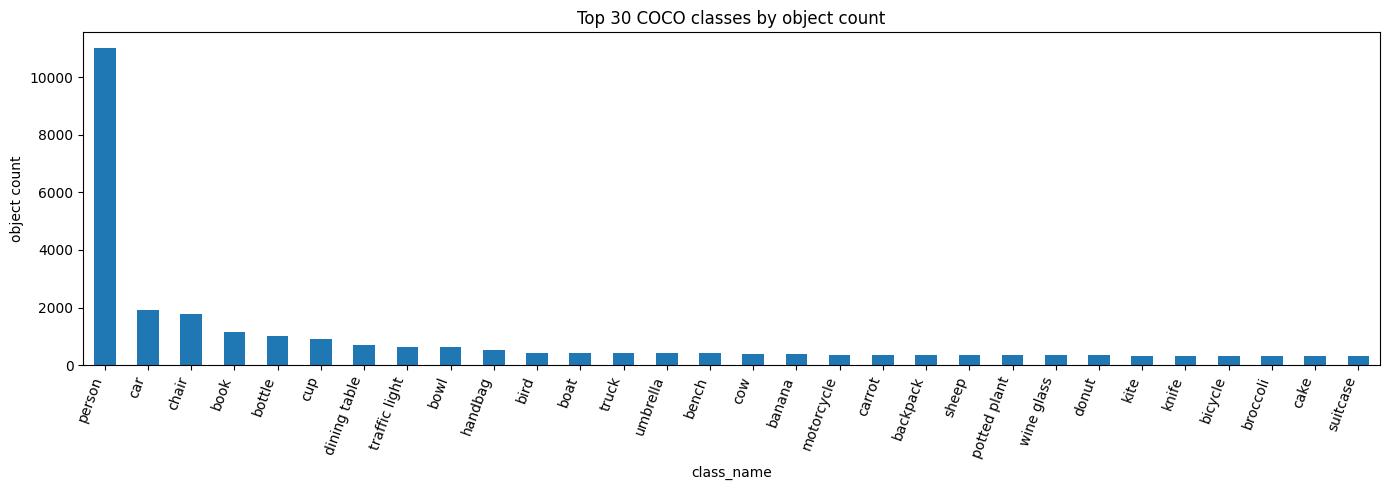

In [108]:
class_counts = anns_df["class_name"].value_counts()
display(class_counts.to_frame("count").head(20))

plt.figure(figsize=(14, 5))
class_counts.head(30).plot(kind="bar")
plt.title("Top 30 COCO classes by object count")
plt.ylabel("object count")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

## 5. BBox Distribution

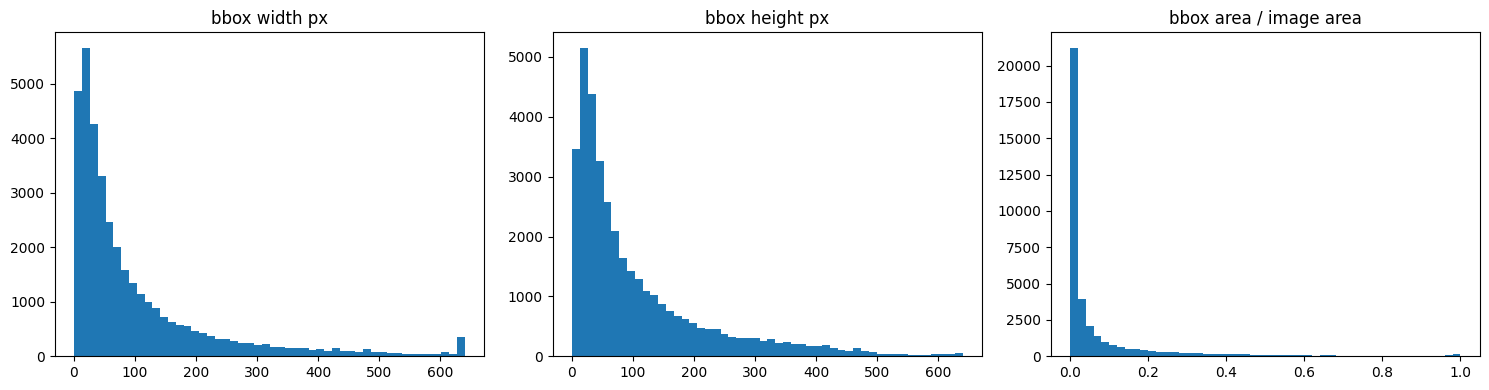

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(anns_df["bbox_w"], bins=50)
axes[0].set_title("bbox width px")

axes[1].hist(anns_df["bbox_h"], bins=50)
axes[1].set_title("bbox height px")

axes[2].hist(anns_df["bbox_area_norm"], bins=50)
axes[2].set_title("bbox area / image area")

plt.tight_layout()
plt.show()

## 6. Xem Ảnh Có Nhiều Object Nhất

In [110]:
top_image_ids = objects_per_image.sort_values(ascending=False).head(10)
top_images = images_df[images_df["id"].isin(top_image_ids.index)].copy()
top_images["num_objects"] = top_images["id"].map(top_image_ids)
display(top_images.sort_values("num_objects", ascending=False))

,license,file_name,coco_url,height,width,date_captured,flickr_url,id,num_objects
938,2,000000435081.jpg,http://images.cocodataset.org/val2017/00000043...,500,500,2013-11-20 01:13:33,http://farm3.staticflickr.com/2573/3676385228_...,435081,63
3692,1,000000470924.jpg,http://images.cocodataset.org/val2017/00000047...,480,640,2013-11-23 04:23:48,http://farm3.staticflickr.com/2442/3747222980_...,470924,56
4605,3,000000303566.jpg,http://images.cocodataset.org/val2017/00000030...,426,640,2013-11-19 18:36:40,http://farm3.staticflickr.com/2350/1558626104_...,303566,56
4651,1,000000018380.jpg,http://images.cocodataset.org/val2017/00000001...,426,640,2013-11-25 14:13:45,http://farm6.staticflickr.com/5474/9701242334_...,18380,54
3314,1,000000031296.jpg,http://images.cocodataset.org/val2017/00000003...,425,640,2013-11-24 22:26:16,http://farm6.staticflickr.com/5534/10153588564...,31296,53
498,2,000000036494.jpg,http://images.cocodataset.org/val2017/00000003...,434,640,2013-11-15 20:09:34,http://farm3.staticflickr.com/2694/4165136971_...,36494,52
744,3,000000224807.jpg,http://images.cocodataset.org/val2017/00000022...,428,640,2013-11-25 14:19:34,http://farm8.staticflickr.com/7281/9610809291_...,224807,46
4925,4,000000166918.jpg,http://images.cocodataset.org/val2017/00000016...,640,480,2013-11-25 19:58:20,http://farm5.staticflickr.com/4117/4745624149_...,166918,45
626,4,000000210273.jpg,http://images.cocodataset.org/val2017/00000021...,428,640,2013-11-15 09:01:55,http://farm6.staticflickr.com/5163/5336041838_...,210273,43
4307,1,000000376322.jpg,http://images.cocodataset.org/val2017/00000037...,640,478,2013-11-25 14:04:13,http://farm4.staticflickr.com/3716/10061418735...,376322,43


## 7. Visualize Random Samples Inline

annotation_index: 0
annotation_id: 1768
image_id: 289343
file_name: 000000289343.jpg
class_name: dog
COCO bbox [x_min, y_min, width, height]: [np.float64(473.07), np.float64(395.93), np.float64(38.65), np.float64(28.67)]


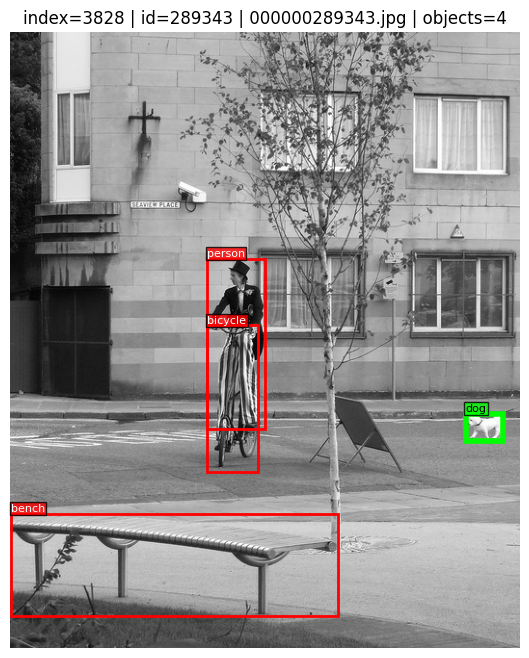

In [111]:
def show_image_with_boxes(image_id, highlight_ann_id=None):
    img_info = images_df[images_df["id"] == image_id].iloc[0]
    img_path = IMAGE_DIR / img_info["file_name"]
    image = Image.open(img_path).convert("RGB")
    image_anns = anns_df[anns_df["image_id"] == image_id]

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"index={img_info.name} | id={image_id} | {img_info['file_name']} | objects={len(image_anns)}")

    for _, ann in image_anns.iterrows():
        is_highlight = highlight_ann_id is not None and ann["id"] == highlight_ann_id
        color = "lime" if is_highlight else "red"
        line_width = 4 if is_highlight else 2

        rect = patches.Rectangle(
            (ann["x_min"], ann["y_min"]),
            ann["bbox_w"],
            ann["bbox_h"],
            linewidth=line_width,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            ann["x_min"],
            max(0, ann["y_min"] - 2),
            ann["class_name"],
            color="black" if is_highlight else "white",
            fontsize=8,
            bbox=dict(facecolor=color, alpha=0.8, pad=1),
        )
    plt.show()


def show_image_by_index(image_index):
    img_info = images_df.iloc[image_index]
    print("image_index:", image_index)
    print("image_id:", img_info["id"])
    print("file_name:", img_info["file_name"])
    show_image_with_boxes(img_info["id"])


def show_image_by_file(file_name):
    img_info = images_df[images_df["file_name"] == file_name].iloc[0]
    print("image_index:", img_info.name)
    print("image_id:", img_info["id"])
    print("file_name:", img_info["file_name"])
    show_image_with_boxes(img_info["id"])


def show_image_by_annotation_index(annotation_index):
    ann = anns_df.iloc[annotation_index]
    print("annotation_index:", annotation_index)
    print("annotation_id:", ann["id"])
    print("image_id:", ann["image_id"])
    print("file_name:", ann["file_name"])
    print("class_name:", ann["class_name"])
    print("COCO bbox [x_min, y_min, width, height]:", [ann["x_min"], ann["y_min"], ann["bbox_w"], ann["bbox_h"]])
    show_image_with_boxes(ann["image_id"], highlight_ann_id=ann["id"])


# Cách 1: xem ảnh theo index trong images_df.
# image_index = 0
# show_image_by_index(image_index)

# Cách 2: xem ảnh theo file name.
# show_image_by_file("000000289343.jpg")

# Cách 3: xem đúng ảnh + bbox của annotation đang convert ở Part 8/9.
annotation_index = 0
show_image_by_annotation_index(annotation_index)

## 8. Convert Một Annotation Sang YOLO Format Thử

Cell này giúp kiểm tra công thức convert trước khi viết converter chính thức.

In [112]:
row = anns_df.iloc[0]

x_center = (row["x_min"] + row["bbox_w"] / 2) / row["width"]
y_center = (row["y_min"] + row["bbox_h"] / 2) / row["height"]
box_w = row["bbox_w"] / row["width"]
box_h = row["bbox_h"] / row["height"]

print("COCO bbox:")
print(row[["class_name", "category_id", "yolo_class_id", "x_min", "y_min", "bbox_w", "bbox_h", "width", "height"]])

print("\nYOLO txt line:")
print(f"{int(row['yolo_class_id'])} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}")

COCO bbox:
class_name          dog
category_id          18
yolo_class_id        16
x_min            473.07
y_min            395.93
bbox_w            38.65
bbox_h            28.67
width               529
height              640
Name: 0, dtype: object

YOLO txt line:
16 0.930803 0.641039 0.073062 0.044797


## 9. So Sánh Annotation Gốc COCO Và Annotation Sau Khi Convert

Cell này lấy 1 annotation, hiển thị cả format COCO gốc và format YOLO sau khi convert. Hình bên trái dùng bbox gốc `[x_min, y_min, width, height]`; hình bên phải vẽ lại bbox từ YOLO normalized để kiểm tra convert có đúng không.

In [113]:
# Chọn annotation muốn xem. Đổi số này để xem annotation khác.
ann_idx = 0
row = anns_df.iloc[ann_idx]

# COCO original format: [x_min, y_min, width, height] theo pixel.
coco_box = [row["x_min"], row["y_min"], row["bbox_w"], row["bbox_h"]]

# YOLO format: [class_id, x_center, y_center, width, height].
# x_center, y_center, width, height đều normalized về khoảng 0..1.
x_center = (row["x_min"] + row["bbox_w"] / 2) / row["width"]
y_center = (row["y_min"] + row["bbox_h"] / 2) / row["height"]
box_w = row["bbox_w"] / row["width"]
box_h = row["bbox_h"] / row["height"]
yolo_box = [int(row["yolo_class_id"]), x_center, y_center, box_w, box_h]

print("Image file:", row["file_name"])
print("Class:", row["class_name"])
print("COCO category_id:", int(row["category_id"]))
print("Mapped YOLO class_id:", int(row["yolo_class_id"]))
print("Image size [width, height]:", [int(row["width"]), int(row["height"])])
print()
print("COCO original bbox [x_min, y_min, width, height] in pixels:")
print(coco_box)
print()
print("YOLO txt line format: class_id x_center y_center width height")
print(f"{yolo_box[0]} {yolo_box[1]:.6f} {yolo_box[2]:.6f} {yolo_box[3]:.6f} {yolo_box[4]:.6f}")

Image file: 000000289343.jpg
Class: dog
COCO category_id: 18
Mapped YOLO class_id: 16
Image size [width, height]: [529, 640]

COCO original bbox [x_min, y_min, width, height] in pixels:
[np.float64(473.07), np.float64(395.93), np.float64(38.65), np.float64(28.67)]

YOLO txt line format: class_id x_center y_center width height
16 0.930803 0.641039 0.073062 0.044797
